# Upscale — learned model (PyTorch)

The smallest thing that counts as a learned upscaler, trained on what
`data_preprocess.ipynb` wrote. It exists to make the rest of the work measurable: a
number to beat, a runtime to fit inside a frame budget, a checkpoint format to keep, and
an inference path from a PNG to a PNG.

The bar is in `upscale_dummy.ipynb` — the static resampling filters, which need no model
and cost a fraction of a millisecond. Beating them on PSNR is not the test; beating them
on PSNR *inside* a frame budget they leave almost entirely unspent is.

It runs in five phases, and each one ends with the check the next one is allowed to
assume:

1. **Data** — the patch pairs as a `Dataset` per split, the loaders over them, and a look
   at what actually comes out.
2. **Model** — the architecture, its input and output sizes, its parameter count, and the
   proof that an untrained model *is* the bicubic baseline.
3. **Training** — the loop, with the same validation measurement taken after every epoch,
   then quality and runtime on the trained weights.
4. **Checkpoint** — save, load back into a fresh model, and verify the two agree before
   anything downstream trusts the file.
5. **Export** — the same weights as ONNX, pinned to the benchmark tile, checked against
   torch and published to the browser page.

In [8]:
"""Configuration — every knob this notebook has."""

from pathlib import Path

DATA_DIR = Path("data/processed")
RAW_DIR = Path("data/raw")
CHECKPOINT_DIR = Path("checkpoints")
SAMPLE_DIR = Path("data/samples")

CHANNELS = 64                  # feature width of the first convolution
EPOCHS = 12
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
SEED = 0

# Runtime: a batch of one at the output sizes a client would ask for, then what batching
# buys at one small size.
BENCH_RESOLUTIONS = [(480, 270), (640, 360), (960, 540), (1280, 720)]
BENCH_LR_SIZE = (320, 180)
BENCH_BATCHES = [1, 2, 4, 8, 16]

In [9]:
"""Imports, device, and the manifest the preprocessing notebook wrote."""

import json
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

if not (DATA_DIR / "manifest.json").exists():
    raise RuntimeError(f"no dataset in {DATA_DIR} — run data_preprocess.ipynb first")

manifest = json.loads((DATA_DIR / "manifest.json").read_text(encoding="utf-8"))
SCALE = manifest["scale"]

print("device      ", DEVICE, torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "")
print("torch       ", torch.__version__)
print("scale       ", SCALE)
print("patch       ", manifest["patch_lr"], "->", manifest["patch_hr"])
print("degradation ", manifest["degradation"])

device       cpu 
torch        2.13.0+cpu
scale        2
patch        64 -> 128
degradation  bicubic downscale


## 1. Data

Two splits, and they are the train and the test set: `val` is held out and every number
in this notebook is measured on it. The split is by *source frame* rather than by patch —
`data_preprocess.ipynb` does that deliberately, because two patches cut from the same
frame overlap and a patch-level split would put the same pixels on both sides of it.

The `.npy` files are memory mapped rather than read: the arrays are small today, but the
access pattern is one random patch at a time, which is exactly what a memory map is for,
and it keeps working when the set outgrows RAM.

The only augmentation is the eight-way dihedral group — flips and 90° rotations. They are
free, they are exact (no resampling, so no new degradation is invented), and they are
applied to LR and HR with the same parameters or the pair stops being a pair. It is on
for training and off for the test split, where a fixed set is the point.

In [10]:
"""Patch pairs as float tensors in [0, 1], with the flip/rotate augmentation."""

class PatchPairs(Dataset):
    def __init__(self, directory, split, manifest, augment):
        info = manifest["splits"][split]
        self.split = split
        self.frames = info["frames"]
        self.lr = np.load(directory / info["lr"], mmap_mode="r")
        self.hr = np.load(directory / info["hr"], mmap_mode="r")
        self.augment = augment

    def __len__(self):
        return len(self.lr)

    def __getitem__(self, index):
        lr = np.asarray(self.lr[index])
        hr = np.asarray(self.hr[index])

        if self.augment:
            turns = int(torch.randint(0, 4, ()))
            lr, hr = np.rot90(lr, turns), np.rot90(hr, turns)
            if int(torch.randint(0, 2, ())):
                lr, hr = lr[:, ::-1], hr[:, ::-1]

        to_tensor = lambda a: torch.from_numpy(
            np.ascontiguousarray(a.transpose(2, 0, 1))).float().div_(255.0)
        return to_tensor(lr), to_tensor(hr)

In [11]:
"""The two dataset objects and the loaders over them."""

train_set = PatchPairs(DATA_DIR, "train", manifest, augment=True)
val_set = PatchPairs(DATA_DIR, "val", manifest, augment=False)

# num_workers stays 0: the patches are already in memory-mapped arrays, and on Windows a
# worker process would re-import this notebook module to get there.
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

print(f"{'split':>6}{'patches':>9}{'frames':>8}{'batches':>9}  augment")
for dataset, loader in [(train_set, train_loader), (val_set, val_loader)]:
    print(f"{dataset.split:>6}{len(dataset):9}{len(dataset.frames):8}{len(loader):9}"
          f"  {'yes' if dataset.augment else 'no'}")

shared = set(train_set.frames) & set(val_set.frames)
print(f"\nframes in both splits: {len(shared)}   (a patch-level split would not manage this)")

lr_batch, hr_batch = next(iter(train_loader))
print(f"lr batch  {tuple(lr_batch.shape)}  {lr_batch.dtype}  "
      f"[{float(lr_batch.min()):.2f}, {float(lr_batch.max()):.2f}]")
print(f"hr batch  {tuple(hr_batch.shape)}  {hr_batch.dtype}  "
      f"[{float(hr_batch.min()):.2f}, {float(hr_batch.max()):.2f}]")

 split  patches  frames  batches  augment
 train      268      10        8  yes
   val       76       2        3  no

frames in both splits: 0   (a patch-level split would not manage this)
lr batch  (32, 3, 64, 64)  torch.float32  [0.00, 1.00]
hr batch  (32, 3, 128, 128)  torch.float32  [0.00, 1.00]


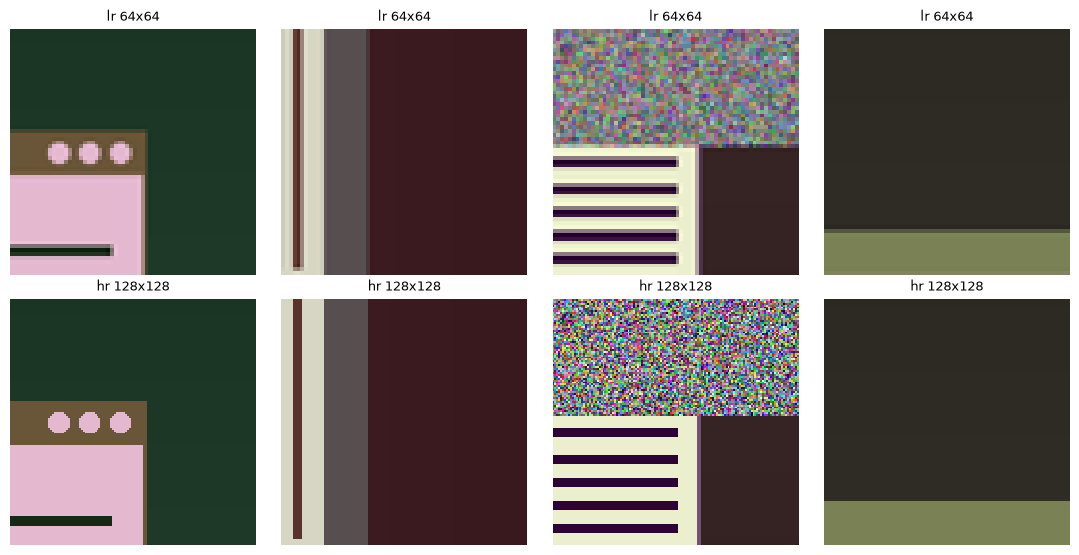

In [12]:
"""What the loader actually hands over: four training pairs, LR over HR."""

picks = np.random.default_rng(SEED).choice(len(train_set), 4, replace=False)

fig, axes = plt.subplots(2, len(picks), figsize=(11, 5.6))
for column, index in enumerate(picks):
    for row, (name, image) in enumerate(zip(("lr", "hr"), train_set[int(index)])):
        axes[row][column].imshow(image.permute(1, 2, 0).numpy(), interpolation="nearest")
        axes[row][column].set_title(f"{name} {image.shape[2]}x{image.shape[1]}", fontsize=9)
        axes[row][column].axis("off")
fig.tight_layout()
plt.show()

## 2. Model

ESPCN-shaped — two convolutions at *low* resolution, then one pixel shuffle. Upscaling
last is the whole point: a network that upsamples first does every convolution over
`SCALE**2` times as many pixels for the same result, which on a live desktop stream is
the difference between keeping up and not.

It learns a **residual on top of bicubic**, and the last convolution starts at zero. So
epoch 0 *is* the bicubic baseline, and every PSNR the training loop prints is the honest
gain over it — a plain network would spend its first epochs relearning interpolation and
the curve would say nothing about whether it works.

It is fully convolutional, so the input size is not fixed: it takes `N x 3 x H x W` in
[0, 1] and returns `N x 3 x H*SCALE x W*SCALE`. Two sizes follow from that and are checked
below — the patch it trains on, and the frame sizes it is measured at.

PSNR is reported on RGB in [0, 1] against the clamped output. It is a poor judge of how an
upscale *looks*, but it is the right judge of whether training is doing anything at all,
which is all this notebook claims to answer.

In [13]:
"""The upscaler, the bicubic baseline it is measured against, and PSNR."""

# The receptive field of the residual path: 5x5 reaches 2 LR pixels, then two 3x3 reach 1
# each. The bicubic base reaches 2, so 4 covers both — this is the halo tiled inference
# has to feed the model, and it travels with the checkpoint and the ONNX graph.
HALO = 4


class ResidualUpscaler(nn.Module):
    def __init__(self, scale, channels=64):
        super().__init__()
        self.scale = scale
        self.features = nn.Sequential(
            nn.Conv2d(3, channels, 5, padding=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels // 2, 3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.residual = nn.Conv2d(channels // 2, 3 * scale * scale, 3, padding=1)
        self.shuffle = nn.PixelShuffle(scale)

        # Start as the identity on top of bicubic: no gradient signal is wasted on
        # relearning interpolation, and epoch 0 measures exactly the baseline.
        nn.init.zeros_(self.residual.weight)
        nn.init.zeros_(self.residual.bias)

    def forward(self, x):
        base = F.interpolate(x, scale_factor=self.scale, mode="bicubic", align_corners=False)
        return base + self.shuffle(self.residual(self.features(x)))


def bicubic(x, scale):
    return F.interpolate(x, scale_factor=scale, mode="bicubic", align_corners=False)


def psnr(prediction, target):
    mse = F.mse_loss(prediction.clamp(0, 1), target, reduction="none").mean(dim=(1, 2, 3))
    return (10.0 * torch.log10(1.0 / mse.clamp_min(1e-12))).mean().item()

In [14]:
"""Build it, and count what it costs to carry."""

model = ResidualUpscaler(SCALE, CHANNELS).to(DEVICE)
print(model, "\n")

print(f"{'parameter':<22}{'shape':<24}{'count':>9}")
for name, parameter in model.named_parameters():
    print(f"{name:<22}{str(tuple(parameter.shape)):<24}{parameter.numel():>9,}")

parameters = sum(p.numel() for p in model.parameters())
print(f"{'total':<22}{'':<24}{parameters:>9,}   ({parameters * 4 / 1e6:.2f} MB as float32)")
print(f"\nscale x{SCALE}, halo {HALO} LR pixels, fully convolutional (no fixed input size)")

ResidualUpscaler(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (residual): Conv2d(32, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (shuffle): PixelShuffle(upscale_factor=2)
) 

parameter             shape                       count
features.0.weight     (64, 3, 5, 5)               4,800
features.0.bias       (64,)                          64
features.2.weight     (32, 64, 3, 3)             18,432
features.2.bias       (32,)                          32
residual.weight       (12, 32, 3, 3)              3,456
residual.bias         (12,)                          12
total                                            26,796   (0.11 MB as float32)

scale x2, halo 4 LR pixels, fully convolutional (no fixed input size)


In [15]:
"""Input and output sizes: the patch it trains on, and the frames it is measured at."""

@torch.no_grad()
def output_shape(model, width, height):
    return tuple(model(torch.zeros(1, 3, height, width, device=DEVICE)).shape)


print(f"{'input':>20}  {'output':>20}   pixels")
for width, height in [(manifest["patch_lr"], manifest["patch_lr"])] + BENCH_RESOLUTIONS:
    shape = output_shape(model, width, height)
    assert shape == (1, 3, height * SCALE, width * SCALE), shape
    print(f"{f'1x3x{height}x{width}':>20}  {f'{shape[0]}x{shape[1]}x{shape[2]}x{shape[3]}':>20}"
          f"   {width * height / 1e3:6.1f}k -> {shape[2] * shape[3] / 1e3:7.1f}k")

               input                output   pixels
           1x3x64x64           1x3x128x128      4.1k ->    16.4k
         1x3x270x480           1x3x540x960    129.6k ->   518.4k
         1x3x360x640          1x3x720x1280    230.4k ->   921.6k
         1x3x540x960         1x3x1080x1920    518.4k ->  2073.6k
        1x3x720x1280         1x3x1440x2560    921.6k ->  3686.4k


In [16]:
"""Average PSNR over a loader, for the model and for the bicubic baseline."""

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    scores, baselines, count = 0.0, 0.0, 0
    for lr, hr in loader:
        lr, hr = lr.to(DEVICE), hr.to(DEVICE)
        n = lr.size(0)
        scores += psnr(model(lr), hr) * n
        baselines += psnr(bicubic(lr, SCALE), hr) * n
        count += n
    return scores / count, baselines / count


start_model, start_baseline = evaluate(model, val_loader)
print(f"before training  model {start_model:.2f} dB   bicubic {start_baseline:.2f} dB")
assert abs(start_model - start_baseline) < 1e-6, "the residual did not start at zero"
print("the two match because the residual starts at zero — the model *is* the baseline")

before training  model 23.41 dB   bicubic 23.41 dB
the two match because the residual starts at zero — the model *is* the baseline


## 3. Training

L1 rather than L2: the same networks trained on L1 come out visibly sharper, because a
squared error is minimised by hedging towards the mean of the plausible outputs, which is
a blur. The loss is still reported next to PSNR, which is an L2 measure — they are allowed
to disagree.

Every epoch ends with the full test measurement: model PSNR, baseline PSNR on the same
patches, and the gap between them. The baseline is recomputed rather than remembered so
the two always come from the same data, and the best epoch is kept by that PSNR rather
than by the loss — a training loss on 268 patches is not evidence about anything.

In [17]:
"""Train, measuring the validation split after every epoch and keeping the best weights."""

optimiser = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
schedule = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=EPOCHS)

history = {"loss": [], "psnr": [], "baseline": []}
best = {"psnr": float("-inf"), "epoch": -1, "state": None}

for epoch in range(EPOCHS):
    model.train()
    started, running, seen = time.time(), 0.0, 0

    for lr, hr in train_loader:
        lr, hr = lr.to(DEVICE), hr.to(DEVICE)
        loss = F.l1_loss(model(lr), hr)

        optimiser.zero_grad(set_to_none=True)
        loss.backward()
        optimiser.step()

        running += loss.item() * lr.size(0)
        seen += lr.size(0)

    schedule.step()
    train_loss = running / seen
    val_psnr, val_baseline = evaluate(model, val_loader)

    history["loss"].append(train_loss)
    history["psnr"].append(val_psnr)
    history["baseline"].append(val_baseline)

    if val_psnr > best["psnr"]:
        best = {"psnr": val_psnr, "epoch": epoch,
                "state": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}}

    print(f"epoch {epoch + 1:2}/{EPOCHS}  l1 {train_loss:.4f}  "
          f"val {val_psnr:.2f} dB  bicubic {val_baseline:.2f} dB  "
          f"gain {val_psnr - val_baseline:+.2f} dB  {time.time() - started:.1f}s")

model.load_state_dict(best["state"])
print(f"\nbest epoch {best['epoch'] + 1} at {best['psnr']:.2f} dB, restored")

epoch  1/12  l1 0.0479  val 23.42 dB  bicubic 23.41 dB  gain +0.01 dB  0.7s
epoch  2/12  l1 0.0450  val 23.31 dB  bicubic 23.41 dB  gain -0.10 dB  0.7s
epoch  3/12  l1 0.0449  val 23.28 dB  bicubic 23.41 dB  gain -0.13 dB  0.7s
epoch  4/12  l1 0.0428  val 23.41 dB  bicubic 23.41 dB  gain +0.00 dB  0.7s
epoch  5/12  l1 0.0424  val 23.57 dB  bicubic 23.41 dB  gain +0.16 dB  0.7s
epoch  6/12  l1 0.0416  val 23.78 dB  bicubic 23.41 dB  gain +0.37 dB  0.7s
epoch  7/12  l1 0.0395  val 23.97 dB  bicubic 23.41 dB  gain +0.56 dB  0.7s
epoch  8/12  l1 0.0385  val 24.11 dB  bicubic 23.41 dB  gain +0.70 dB  0.7s
epoch  9/12  l1 0.0390  val 24.24 dB  bicubic 23.41 dB  gain +0.82 dB  0.7s
epoch 10/12  l1 0.0374  val 24.30 dB  bicubic 23.41 dB  gain +0.88 dB  0.7s
epoch 11/12  l1 0.0380  val 24.30 dB  bicubic 23.41 dB  gain +0.89 dB  0.7s
epoch 12/12  l1 0.0374  val 24.31 dB  bicubic 23.41 dB  gain +0.90 dB  0.7s

best epoch 12 at 24.31 dB, restored


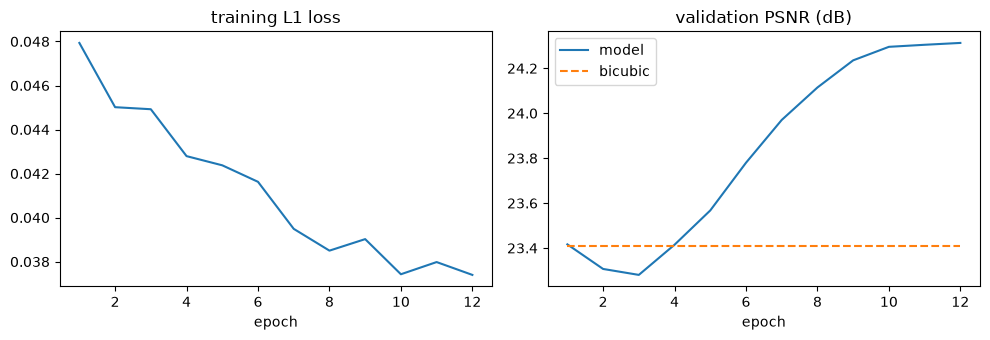

In [18]:
"""Loss and PSNR against the baseline."""

fig, (left, right) = plt.subplots(1, 2, figsize=(10, 3.5))
epochs = range(1, len(history["loss"]) + 1)

left.plot(epochs, history["loss"])
left.set_title("training L1 loss")
left.set_xlabel("epoch")

right.plot(epochs, history["psnr"], label="model")
right.plot(epochs, history["baseline"], "--", label="bicubic")
right.set_title("validation PSNR (dB)")
right.set_xlabel("epoch")
right.legend()

fig.tight_layout()
plt.show()

In [19]:
"""What training bought, on the split it never trained on."""

final_psnr, final_baseline = evaluate(model, val_loader)

print(f"{'':>22}{'model':>9}{'bicubic':>10}{'gain':>11}")
for name, score, baseline in [("before training", start_model, start_baseline),
                              (f"best epoch {best['epoch'] + 1}", final_psnr, final_baseline)]:
    print(f"{name:>22}{score:9.2f}{baseline:10.2f}{score - baseline:+10.2f} dB")

print(f"\n{final_psnr - start_model:+.2f} dB over where it started, "
      f"on {len(val_set)} patches from {len(val_set.frames)} held-out frames")

                          model   bicubic       gain
       before training    23.41     23.41     +0.00 dB
         best epoch 12    24.31     23.41     +0.90 dB

+0.90 dB over where it started, on 76 patches from 2 held-out frames


### What it looks like

The numbers say the model beats bicubic; this says where. Look at the text-like rows and
the window edges, which is where a screen stream lives — a gain that shows up only on the
noise block is a model that has learned to sharpen randomness.

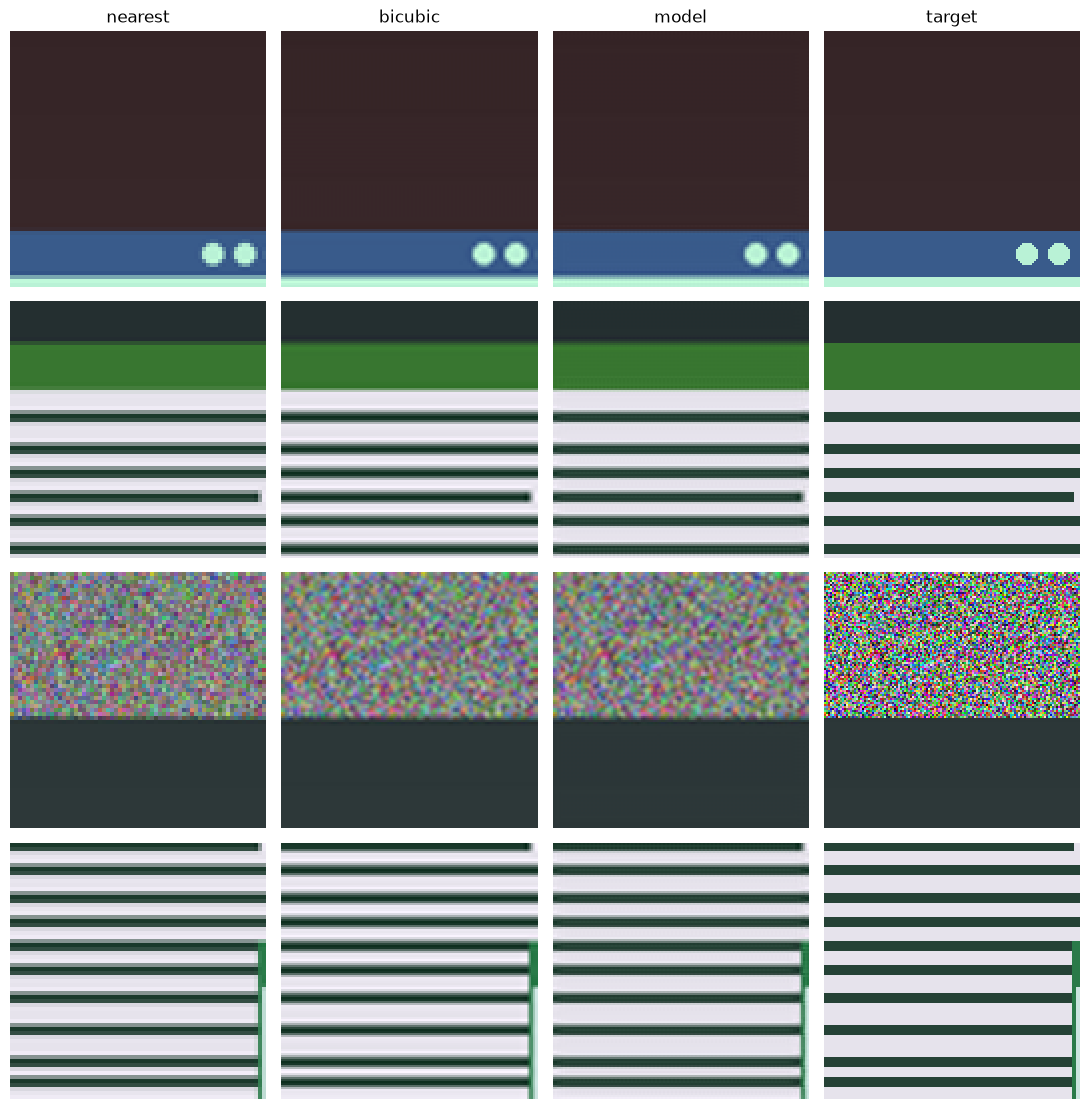

In [20]:
"""Nearest / bicubic / model / target, on validation patches."""

@torch.no_grad()
def compare(model, dataset, count=4):
    model.eval()
    picks = np.random.default_rng(SEED).choice(len(dataset), min(count, len(dataset)), replace=False)
    lr = torch.stack([dataset[int(i)][0] for i in picks]).to(DEVICE)
    hr = torch.stack([dataset[int(i)][1] for i in picks]).to(DEVICE)

    columns = {
        "nearest": F.interpolate(lr, scale_factor=SCALE, mode="nearest"),
        "bicubic": bicubic(lr, SCALE),
        "model": model(lr),
        "target": hr,
    }

    fig, axes = plt.subplots(len(picks), 4, figsize=(11, 2.8 * len(picks)))
    axes = np.atleast_2d(axes)
    for row in range(len(picks)):
        for column, (name, images) in enumerate(columns.items()):
            image = images[row].clamp(0, 1).cpu().permute(1, 2, 0).numpy()
            axes[row][column].imshow(image, interpolation="nearest")
            axes[row][column].axis("off")
            if row == 0:
                axes[row][column].set_title(name)
    fig.tight_layout()
    plt.show()


compare(model, val_set)

### Runtime

For a live stream the runtime is not a footnote to the PSNR, it is half the result: an
upscaler that cannot clear the frame budget is not an upscaler, whatever it scores. Two
measurements, and they answer different questions.

**Batch of one** is the honest number for a stream. Frames arrive one at a time and each
one is wanted now, so there is nothing to batch with — the per-frame cost at batch 1 is
what has to fit inside the frame interval (16.7 ms at 60 fps, 33.3 ms at 30 fps),
alongside decoding, drawing and everything else the client is doing.

**The batch sweep** is what a batch buys. Larger batches amortise the per-call overhead
and keep a wide device fed, so the cost *per frame* can fall — while the latency of any
one frame rises with the batch it waits in. But a CPU already spreading a single frame
across every core has nothing left to win, and then a batch is pure added latency. Which
of the two happens is why this is measured rather than assumed.

Timings are a forward pass only — no data loading, no PNG encoding, and on CUDA they are
taken after a synchronise, since the queue would otherwise return before the work is done.

In [21]:
"""Time one forward pass at a given batch size and input size."""

@torch.no_grad()
def benchmark(model, batch, lr_size, device, seconds=1.0, warmup=2):
    model.eval()
    width, height = lr_size
    x = torch.rand(batch, 3, height, width, device=device)

    def sync():
        if device.type == "cuda":
            torch.cuda.synchronize()

    for _ in range(warmup):
        model(x)
    sync()

    # One timed pass sets how many the measurement can afford inside `seconds`.
    started = time.perf_counter()
    model(x)
    sync()
    once = time.perf_counter() - started

    reps = max(3, min(50, int(seconds / max(once, 1e-6))))
    started = time.perf_counter()
    for _ in range(reps):
        model(x)
    sync()
    elapsed = (time.perf_counter() - started) / reps

    return {
        "batch": batch,
        "in": f"{width}x{height}",
        "out": f"{width * SCALE}x{height * SCALE}",
        "reps": reps,
        "ms_batch": elapsed * 1000,
        "ms_frame": elapsed * 1000 / batch,
        "fps": batch / elapsed,
    }


print(f"{DEVICE.type}, {torch.get_num_threads()} threads" if DEVICE.type == "cpu"
      else f"{torch.cuda.get_device_name(0)}")

cpu, 12 threads


In [22]:
"""Batch of one, at the resolutions a client would actually ask for."""

single = [benchmark(model, 1, size, DEVICE) for size in BENCH_RESOLUTIONS]

print(f"{'output':>12}  {'ms/frame':>9}  {'fps':>7}   frame budget")
for row in single:
    budget = ("60 fps" if row["ms_frame"] <= 16.7 else
              "30 fps" if row["ms_frame"] <= 33.3 else
              "under 30 fps")
    print(f"{row['out']:>12}  {row['ms_frame']:9.1f}  {row['fps']:7.1f}   {budget}")

      output   ms/frame      fps   frame budget
     960x540       24.8     40.3   30 fps
    1280x720       43.8     22.8   under 30 fps
   1920x1080      104.1      9.6   under 30 fps
   2560x1440      201.2      5.0   under 30 fps


In [23]:
"""What a batch buys: per-frame cost against the latency of the batch itself."""

sweep = [benchmark(model, batch, BENCH_LR_SIZE, DEVICE) for batch in BENCH_BATCHES]

print(f"input {sweep[0]['in']} -> {sweep[0]['out']}\n")
print(f"{'batch':>5}  {'ms/batch':>9}  {'ms/frame':>9}  {'fps':>8}  {'vs batch 1':>10}")
for row in sweep:
    print(f"{row['batch']:5}  {row['ms_batch']:9.1f}  {row['ms_frame']:9.2f}  "
          f"{row['fps']:8.1f}  {sweep[0]['ms_frame'] / row['ms_frame']:9.2f}x")

input 320x180 -> 640x360

batch   ms/batch   ms/frame       fps  vs batch 1
    1        9.6       9.60     104.2       1.00x
    2       21.4      10.68      93.6       0.90x
    4       43.4      10.85      92.2       0.88x
    8       90.9      11.36      88.0       0.84x
   16      199.9      12.49      80.0       0.77x


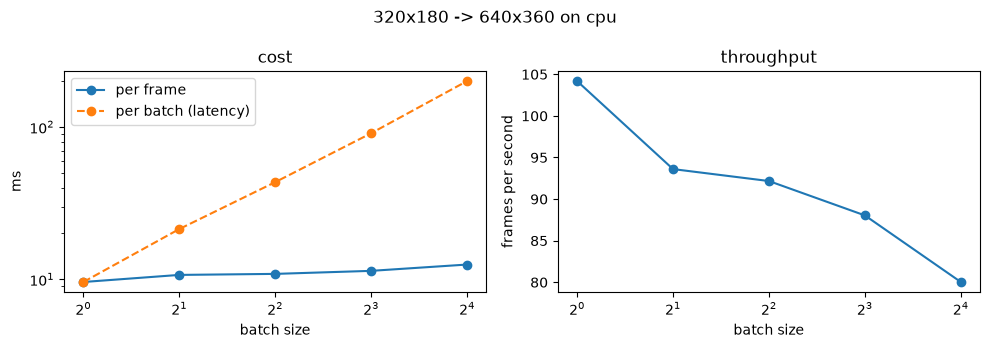

In [24]:
"""The same sweep as a picture: per-frame cost, batch latency, and throughput."""

fig, (left, right) = plt.subplots(1, 2, figsize=(10, 3.5))
batches = [row["batch"] for row in sweep]

left.plot(batches, [row["ms_frame"] for row in sweep], "o-", label="per frame")
left.plot(batches, [row["ms_batch"] for row in sweep], "o--", label="per batch (latency)")
left.set_xscale("log", base=2)
left.set_yscale("log")
left.set_xlabel("batch size")
left.set_ylabel("ms")
left.set_title("cost")
left.legend()

right.plot(batches, [row["fps"] for row in sweep], "o-")
right.set_xscale("log", base=2)
right.set_xlabel("batch size")
right.set_ylabel("frames per second")
right.set_title("throughput")

fig.suptitle(f"{sweep[0]['in']} -> {sweep[0]['out']} on {DEVICE.type}")
fig.tight_layout()
plt.show()

## 4. Checkpoint — save it, load it back, check it survived

The weights alone are not a model — the scale factor, the feature width, the halo and the
degradation they were trained for all have to come back with them, or inference silently
reconstructs the wrong architecture and nothing says so.

Which is why saving is only half of this phase. The file is loaded straight back into a
*fresh* `ResidualUpscaler` built from what the checkpoint itself claims, and the two are
compared three ways: the same tensors, the same output on a probe, and the same PSNR on
the test split as the number stored beside them. A checkpoint that fails any of the three
is a checkpoint whose numbers belong to a model that no longer exists.

In [25]:
"""Save the weights next to everything needed to rebuild the model."""

checkpoint_path = CHECKPOINT_DIR / "upscale_nn.pt"
torch.save({
    "architecture": "ResidualUpscaler",
    "state_dict": model.state_dict(),
    "scale": SCALE,
    "channels": CHANNELS,
    "halo": HALO,
    "epochs": EPOCHS,
    "best_epoch": best["epoch"] + 1,
    "val_psnr": best["psnr"],
    "val_psnr_bicubic": history["baseline"][-1],
    "degradation": manifest["degradation"],
    "trained": time.strftime("%Y-%m-%dT%H:%M:%S"),
}, checkpoint_path)

print(f"{checkpoint_path.resolve()}  ({checkpoint_path.stat().st_size / 1e6:.2f} MB)")

C:\Users\henrik\Downloads\desktop-streamer\model\upscale\checkpoints\upscale_nn.pt  (0.11 MB)


In [26]:
"""Load it back into a fresh model, and check the two are the same model."""

def load_upscaler(path, device):
    checkpoint = torch.load(path, map_location=device, weights_only=True)
    restored = ResidualUpscaler(checkpoint["scale"], checkpoint["channels"]).to(device)
    restored.load_state_dict(checkpoint["state_dict"])
    restored.eval()
    return restored, checkpoint


loaded, checkpoint = load_upscaler(checkpoint_path, DEVICE)
for key, value in checkpoint.items():
    if key != "state_dict":
        print(f"{key:<18} {value}")

saved_state, loaded_state = model.state_dict(), loaded.state_dict()
assert saved_state.keys() == loaded_state.keys(), "the checkpoint lost a tensor"
assert all(torch.equal(saved_state[key].cpu(), loaded_state[key].cpu())
           for key in saved_state), "a tensor came back changed"

model.eval()
probe = torch.rand(2, 3, manifest["patch_lr"], manifest["patch_lr"], device=DEVICE)
with torch.no_grad():
    difference = float((model(probe) - loaded(probe)).abs().max())
assert difference <= 1e-6, f"the loaded model computes something else ({difference:.2e})"

loaded_psnr, _ = evaluate(loaded, val_loader)
assert abs(loaded_psnr - checkpoint["val_psnr"]) < 0.01, "the stored PSNR is not this model's"

print(f"\n{len(saved_state)} tensors identical")
print(f"outputs identical on a {tuple(probe.shape)} probe (max abs difference {difference:.1e})")
print(f"validation PSNR {loaded_psnr:.2f} dB, checkpoint claims {checkpoint['val_psnr']:.2f} dB")

architecture       ResidualUpscaler
scale              2
channels           64
halo               4
epochs             12
best_epoch         12
val_psnr           24.312824048494036
val_psnr_bicubic   23.4108819459614
degradation        bicubic downscale
trained            2026-09-04T15:05:08

6 tensors identical
outputs identical on a (2, 3, 64, 64) probe (max abs difference 0.0e+00)
validation PSNR 24.31 dB, checkpoint claims 24.31 dB


### Inference on a whole frame

Everything below runs on `loaded` rather than on `model` — the checkpoint is the artefact
that leaves this notebook, so it is the one the pictures should come from.

Patches were a training convenience; the model is fully convolutional, so it runs on a
frame of any size in one pass. Whole frames only work while they fit in memory — a 4K
input needs tiling with a halo of real pixels around each tile, which is what `HALO` is
and what the browser page runs.

In [27]:
"""Downscale a source frame and upscale it back, so there is a ground truth to compare to."""

@torch.no_grad()
def upscale_image(model, image, device):
    x = torch.from_numpy(np.asarray(image.convert("RGB")).transpose(2, 0, 1))
    x = x.float().div_(255.0).unsqueeze(0).to(device)
    y = model(x).clamp(0, 1).squeeze(0).mul(255.0).round().byte()
    return Image.fromarray(y.cpu().permute(1, 2, 0).numpy())


source = sorted(RAW_DIR.glob("*.png"))[0]
truth = Image.open(source).convert("RGB")
truth = truth.crop((0, 0, truth.width - truth.width % SCALE, truth.height - truth.height % SCALE))
small = truth.resize((truth.width // SCALE, truth.height // SCALE), Image.BICUBIC)

started = time.time()
restored = upscale_image(loaded, small, DEVICE)
elapsed = time.time() - started

restored.save(SAMPLE_DIR / "upscaled.png")
small.resize(truth.size, Image.BICUBIC).save(SAMPLE_DIR / "bicubic.png")

print(f"{source.name}  {small.size} -> {restored.size} in {elapsed * 1000:.0f} ms "
      f"({1 / elapsed:.1f} fps at this size on {DEVICE.type})")
print("written to", SAMPLE_DIR.resolve())

synthetic_0000.png  (480, 300) -> (960, 600) in 32 ms (31.2 fps at this size on cpu)
written to C:\Users\henrik\Downloads\desktop-streamer\model\upscale\data\samples


C:\Users\henrik\AppData\Local\Temp\ipykernel_9708\2706238664.py:5: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  x = torch.from_numpy(np.asarray(image.convert("RGB")).transpose(2, 0, 1))


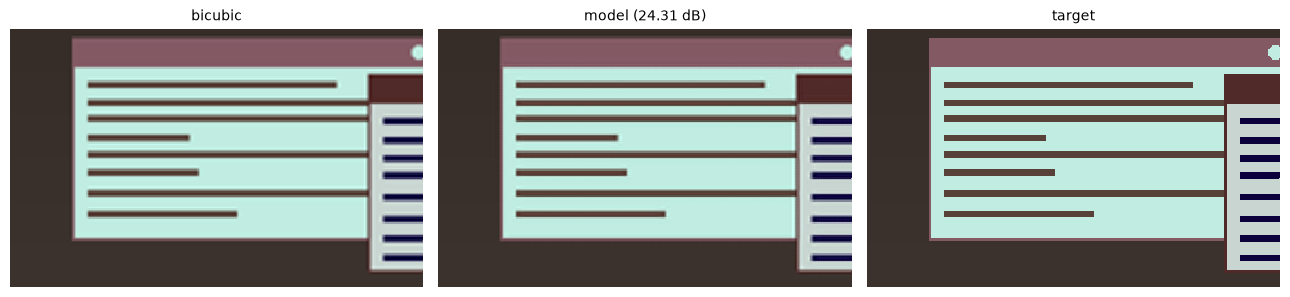

full frame PSNR  bicubic 23.88 dB   model 24.34 dB


In [28]:
"""The same crop through both paths, at 1:1 pixels."""

box = (0, 0, min(320, truth.width), min(200, truth.height))
panels = {
    "bicubic": small.resize(truth.size, Image.BICUBIC).crop(box),
    f"model ({checkpoint['val_psnr']:.2f} dB)": restored.crop(box),
    "target": truth.crop(box),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, (name, image) in zip(axes, panels.items()):
    ax.imshow(image, interpolation="nearest")
    ax.set_title(name, fontsize=10)
    ax.axis("off")
fig.tight_layout()
plt.show()

as_array = lambda image: np.asarray(image, dtype=np.float32) / 255.0
mse = lambda a, b: float(np.mean((a - b) ** 2))
truth_array = as_array(truth)
print(f"full frame PSNR  bicubic "
      f"{10 * np.log10(1 / mse(as_array(small.resize(truth.size, Image.BICUBIC)), truth_array)):.2f} dB"
      f"   model {10 * np.log10(1 / mse(as_array(restored), truth_array)):.2f} dB")

## 5. Export to ONNX for the browser

The checkpoint above is a torch artefact and the client is a browser, so the model has to
leave here as ONNX too, pinned to the tile the benchmark page runs, and published beside
the other candidates. A model that is only ever measured on this machine is a model
nobody can choose against.

The export reads the *checkpoint* rather than the live `model`, for the same reason the
pictures above do: it is the file everything downstream sees, and an export path that
never touches it is an export path that cannot catch a bad save.

**This one exports badly, and that is worth seeing rather than hiding.** The residual sits
on top of a *bicubic* upsample, which is `F.interpolate` here and becomes `Resize` with
`mode="cubic"` in the graph — an operator the WebGPU provider is least likely to run
natively, in the middle of a graph that is otherwise plain convolutions. A fallback there
is not a slower kernel; it copies the tensor out of GPU memory to the CPU and back, once
per frame. The cell prints the operator list and flags anything outside the budget, so the
problem is visible in the output rather than in a comment.

The fix is a skip connection that is not a `Resize` at all — a frozen 1×1 convolution
feeding `DepthToSpace` is bit-exact nearest-neighbour upsampling — and it belongs in the
notebook of whichever model is built that way, not here. This one stays on the page as the
measurement of what the expensive skip costs.

The tile it is pinned to is `webexport.TILE_STEP` plus the halo the checkpoint carries on
each side, so the graph states its own geometry and the page reads it back out of the file.

In [29]:
"""Export the trained model for the browser and publish it to the benchmark page."""

import onnxruntime as ort

import webexport

size = webexport.TILE_STEP + 2 * checkpoint["halo"]

exported, _ = load_upscaler(checkpoint_path, torch.device("cpu"))
info = webexport.export(exported, f"upscale_nn_tile{webexport.TILE_STEP}.onnx", size,
                        label="nn - bicubic residual (has Resize)", halo=checkpoint["halo"])
path = info["path"]

# The graph has to compute what the checkpoint computes, or the page benchmarks a model
# that no measurement in this notebook applies to.
options = ort.SessionOptions()
options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
runtime = ort.InferenceSession(str(path), options, providers=["CPUExecutionProvider"])

probe = torch.rand(1, 3, size, size)
expected = exported(probe).detach().numpy()
actual = runtime.run(None, {"input": probe.numpy()})[0]
print(f"torch vs onnxruntime: max abs difference {np.abs(expected - actual).max():.2e}")

sample = np.random.rand(1, 3, size, size).astype(np.float32)
runtime.run(None, {"input": sample})
started = time.perf_counter()
for _ in range(20):
    runtime.run(None, {"input": sample})
cpu_ms = (time.perf_counter() - started) / 20 * 1000

print(f"{size}x{size} -> {size * SCALE}x{size * SCALE}, keeps "
      f"{webexport.TILE_STEP * SCALE}x{webexport.TILE_STEP * SCALE}   "
      f"{info['kb']} KB   {cpu_ms:.2f} ms/tile on the desktop CPU runtime")
print(f"operators: {', '.join(f'{op}x{n}' for op, n in sorted(info['ops'].items()))}")
if info["outside_budget"]:
    print(f"outside the WebGPU op budget: {', '.join(info['outside_budget'])}"
          f"  <- expect a CPU fallback in the browser")

# The page reads this back out of the file: there is no manifest to write it to. The
# parameter count and the operator list it also shows come out of the graph itself.
webexport.annotate(info, cpu_ms=round(cpu_ms, 2))
print(f"written to {path.resolve()}")

torch vs onnxruntime: max abs difference 1.19e-07
136x136 -> 272x272, keeps 256x256   106.3 KB   56.45 ms/tile on the desktop CPU runtime
operators: Addx1, Constantx1, Convx3, DepthToSpacex1, Relux2, Resizex1
outside the WebGPU op budget: Resize  <- expect a CPU fallback in the browser
written to C:\Users\henrik\Downloads\desktop-streamer\model\upscale\benchmark\www\models\upscale_nn_tile128.onnx


To see what that costs, serve the page and run this model against the static filters
published by `upscale_dummy.ipynb`:

```
uv run upscale/benchmark/main.py       # from model/, then open http://127.0.0.1:8000
```